<a href="https://colab.research.google.com/github/vuhung16au/MachineLearning-GenAI/blob/main/Distances_in_Data_Science_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

This Notebook introduces measure spaces and widely used measure (distance) used in Data Science and Machine Learning.

Distances covered in this Notebook:

- Manhattan Distance
- Euclidean Distance
- Chebyshev Distance
- Minkowski Distance
- Mahalanobis Distance

Means, which is widely used in Probability/Statistics and famous inequalities are also covered.

If you come from Maths to Data Science/Machine Learning or if you need a quick refresher on Maths/DS/ML, this is the right place.

# Manhattan Distance (Taxicab Distance)

In $\mathbb{R}^2$, the taxicab distance between $\mathbf{x} = (x_1, x_2)$ and $\mathbf{y} = (y_1, y_2)$ is $$|x_1 - y_1| + |x_2 - y_2|$$

In $\mathbb{R}^3$, the taxicab distance (also known as Manhattan distance or L1 distance) between two points $\mathbf{x} = (x_1, x_2, x_3)$ and $\mathbf{y} = (y_1, y_2, y_3)$ is defined as:

$$ d_T(\mathbf{x}, \mathbf{y}) = |x_1 - y_1| + |x_2 - y_2| + |x_3 - y_3| $$

In general, the taxicab distance, $d_T$, between two points $\mathbf{x} = (x_1, x_2, \dots, x_n)$ and $\mathbf{y} = (y_1, y_2, \dots, y_n)$ in an $n$-dimensional real coordinate space with a fixed Cartesian coordinate system, is the sum of the lengths of the projections of the line segment between the points onto the coordinate axes.

$$ d_T(\mathbf{x}, \mathbf{y}) = ||\mathbf{x} - \mathbf{y}||_T = \sum_{i=1}^n |x_i - y_i| $$




## NYC Manhattan Map

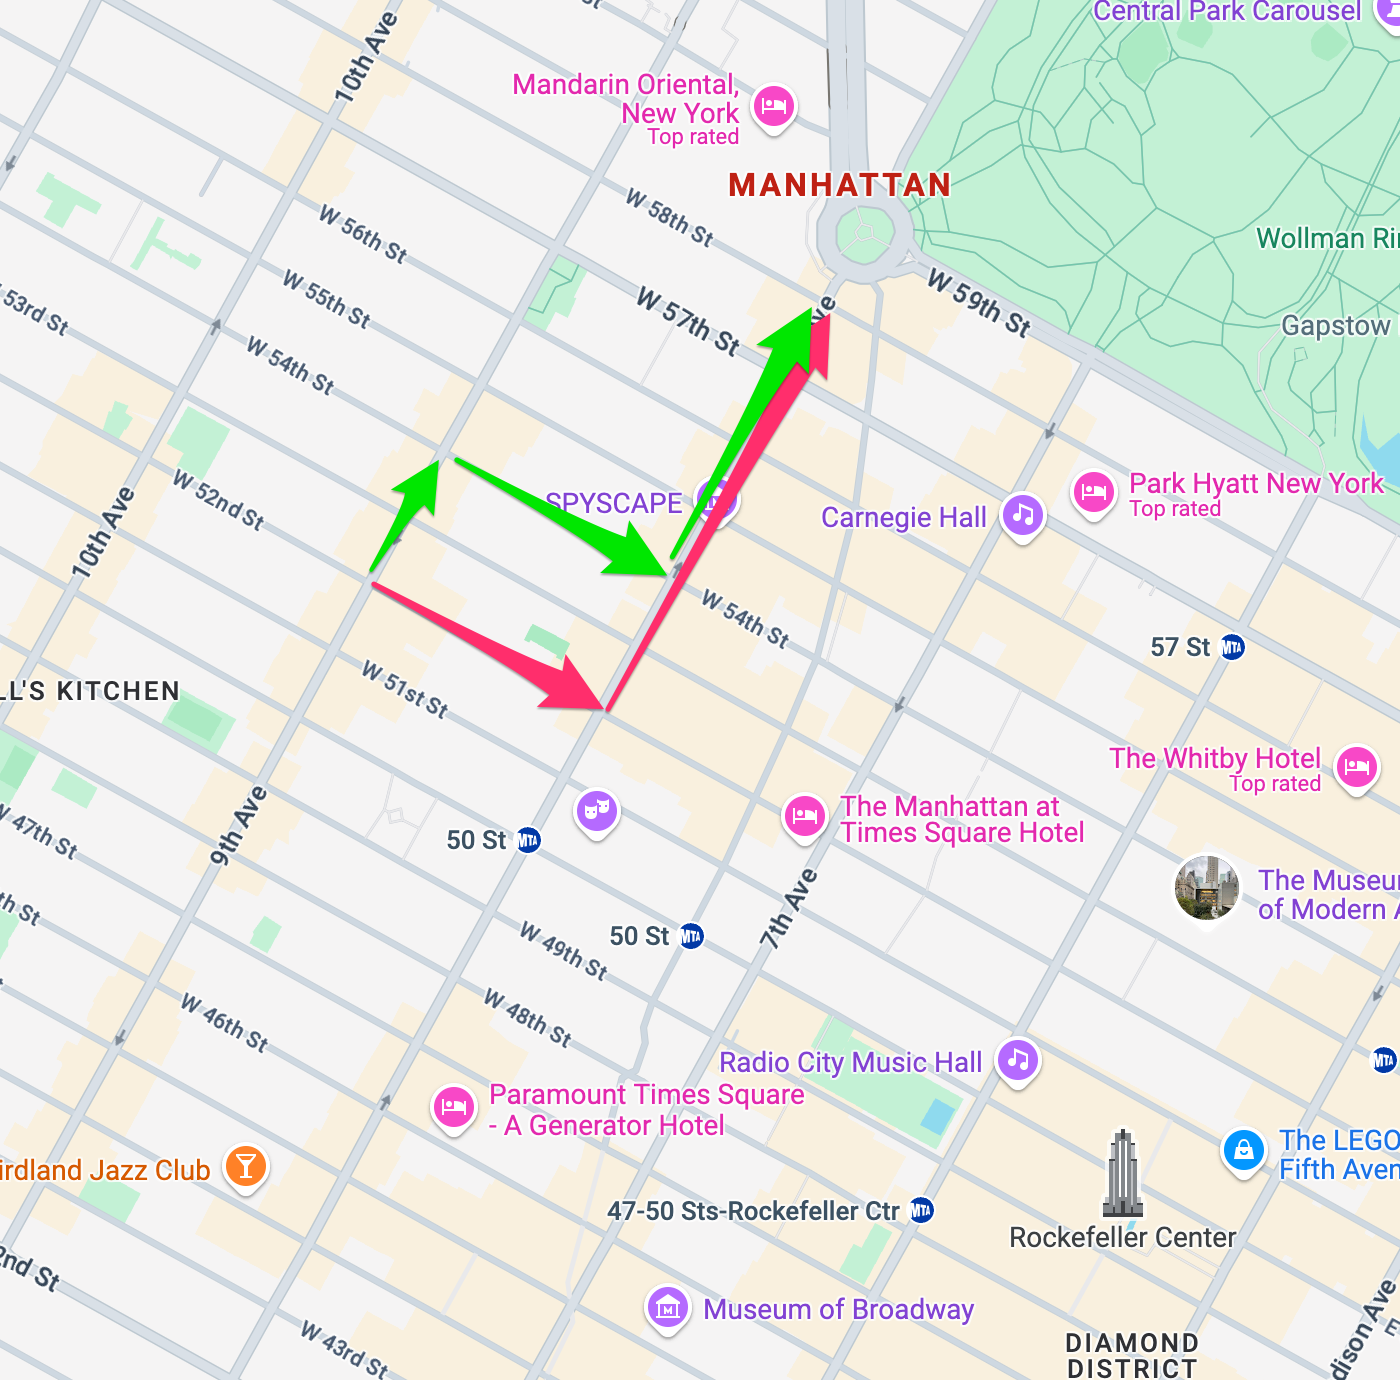

## Calculating Manhattan Distance

In [ ]:

import numpy as np

def manhattan_distance(point1, point2):
  """
  Calculates the Manhattan distance between two points.

  Args:
    point1: A list or numpy array representing the coordinates of the first point.
    point2: A list or numpy array representing the coordinates of the second point.

  Returns:
    The Manhattan distance between the two points.
  """
  point1 = np.array(point1)
  point2 = np.array(point2)
  return np.sum(np.abs(point1 - point2))

# Example usage:
point1 = [1, 2, 3]
point2 = [4, 5, 6]

distance = manhattan_distance(point1, point2)
print(f"Manhattan distance (numpy) between {point1} and {point2} is: {distance}")


Manhattan distance (numpy) between [1, 2, 3] and [4, 5, 6] is: 9


In [ ]:
from scipy.spatial.distance import cityblock
point_a = (1, 2, 3)
point_b = (4, 5, 6)
distance_scipy = cityblock(point_a, point_b)
print(f"Manhattan distance (SciPy): {distance_scipy}")

Manhattan distance (SciPy): 9


## Applications of Manhattan Distance

(https://www.datacamp.com/tutorial/manhattan-distance)

- Pathfinding algorithms (e.g., A* algorithm)
- Clustering techniques (e.g., K-Means clustering)
- Image recognition
- Outlier detection


## King's Travels on Chessboard

### Case 01:
- King can move to the right/left/up/down but not diagonally

### Case 02:
- King can move to the right/left/up/down/diagonally (same as King in Chess)

What is the shortest path for a King to move from (0, 0) to (7, 7)

Note: (0, 0), (7, 7) in the chessboard below, are a1 and h8 in a real chessboard.


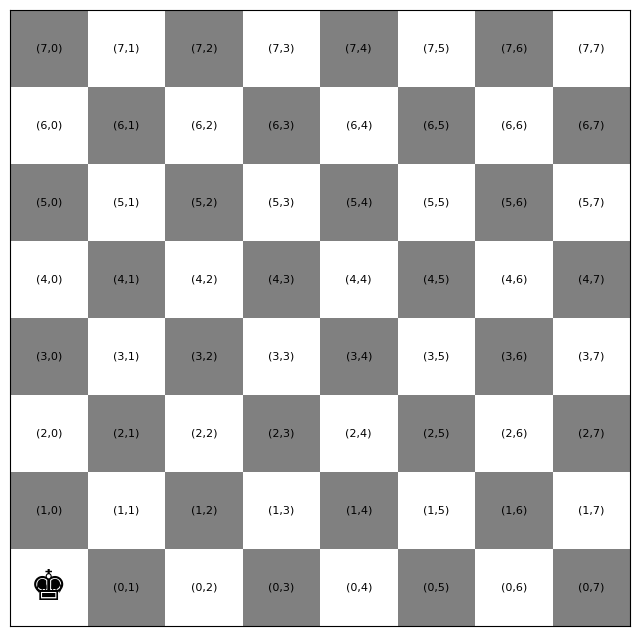

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_chessboard_with_king_and_coords(size=8, king_pos=(0, 0)):
    """Draws a chessboard with a king at the specified position and coordinates on each square."""

    fig, ax = plt.subplots(figsize=(size, size))
    ax.set_xlim(0, size)
    ax.set_ylim(0, size)
    ax.set_xticks([])
    ax.set_yticks([])

    for i in range(size):
        for j in range(size):
            color = 'white' if (i + j) % 2 == 0 else 'gray'
            rect = patches.Rectangle((j, i), 1, 1, facecolor=color)
            ax.add_patch(rect)

            # Add coordinates (i, j) to each square
            ax.text(j + 0.5, i + 0.5, f"({i},{j})", fontsize=8, ha='center', va='center')

    # Add the king unicode character
    ax.text(king_pos[1] + 0.5, king_pos[0] + 0.5, u'\u265A', fontsize=30, ha='center', va='center')

    plt.show()

# Place King on (0, 0)
king_pos = (0, 0)

draw_chessboard_with_king_and_coords(king_pos=king_pos)

# Euclidean Distance

## Definitions of Euclidean Distance (in 1D, 2D spaces)

### One Dimension ($\mathbb{R}^1$)

For points $x$ and $y$ on the real number line, the Euclidean distance is simply the absolute difference between them:

$$ d(x, y) = |x - y| $$

### Two Dimensions ($\mathbb{R}^2$)

For points $\mathbf{x} = (x_1, x_2)$ and $\mathbf{y} = (y_1, y_2)$ given by their Cartesian coordinates, the Euclidean distance is:

$$ d(\mathbf{x}, \mathbf{y}) = \sqrt{(x_1 - y_1)^2 + (x_2 - y_2)^2} $$

### Three Dimensions ($\mathbb{R}^3$)

For points $\mathbf{x} = (x_1, x_2, x_3)$ and $\mathbf{y} = (y_1, y_2, y_3)$ given by their Cartesian coordinates, the Euclidean distance is:

$$ d(\mathbf{x}, \mathbf{y}) = \sqrt{(x_1 - y_1)^2 + (x_2 - y_2)^2 + (x_3 - y_3)^2} $$

### n-Dimensional Euclidean Space ($\mathbb{R}^n$)

In general, for points $\mathbf{x} = (x_1, x_2, \dots, x_n)$ and $\mathbf{y} = (y_1, y_2, \dots, y_n)$ given by their Cartesian coordinates in $n$-dimensional Euclidean space, the Euclidean distance is:

$$ d(\mathbf{x}, \mathbf{y}) = \sqrt{(x_1 - y_1)^2 + (x_2 - y_2)^2 + \dots + (x_n - y_n)^2} $$

We also write,

$$ d(\mathbf{x}, \mathbf{y}) = ||\mathbf{x} - \mathbf{y}|| $$



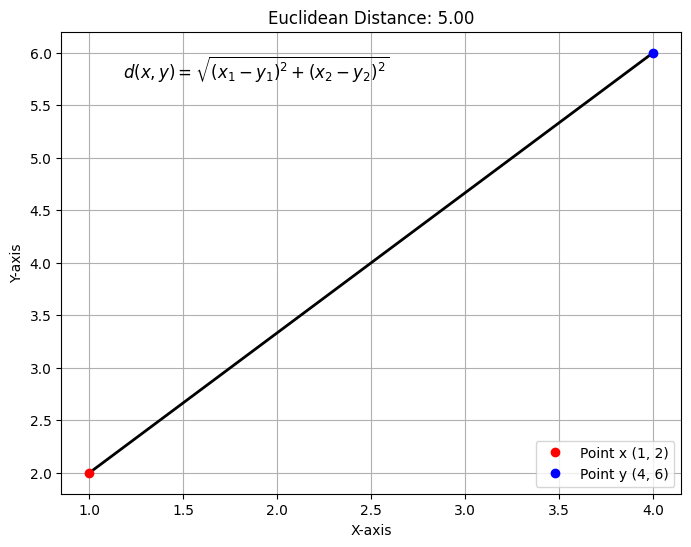

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def euclidean_distance(x, y):
  """Calculates the Euclidean distance between two points in 2D space.

  Args:
    x: A tuple or list representing the coordinates of point x (x1, x2).
    y: A tuple or list representing the coordinates of point y (y1, y2).

  Returns:
    The Euclidean distance between x and y.
  """
  return np.sqrt((x[0] - y[0])**2 + (x[1] - y[1])**2)

def plot_points_and_distance(x, y):
  """Plots the points x and y, the line representing the distance, and the formula.

  Args:
    x: A tuple or list representing the coordinates of point x (x1, x2).
    y: A tuple or list representing the coordinates of point y (y1, y2).
  """
  distance = euclidean_distance(x, y)

  plt.figure(figsize=(8, 6))
  plt.plot([x[0], y[0]], [x[1], y[1]], 'k-', linewidth=2)  # Line connecting x and y
  plt.plot(x[0], x[1], 'ro', label=f'Point x ({x[0]}, {x[1]})')  # Plot point x with coordinates
  plt.plot(y[0], y[1], 'bo', label=f'Point y ({y[0]}, {y[1]})')  # Plot point y with coordinates

  plt.xlabel('X-axis')
  plt.ylabel('Y-axis')
  plt.title(f'Euclidean Distance: {distance:.2f}')
  plt.grid(True)
  plt.legend()

  # Add the formula to the plot
  formula = r'$d(x, y) = \sqrt{(x_1 - y_1)^2 + (x_2 - y_2)^2}$'
  plt.text(0.1, 0.9, formula, transform=plt.gca().transAxes, fontsize=12)

  plt.show()


x = (1, 2)
y = (4, 6)

plot_points_and_distance(x, y)

## Applications of Euclidean Distance
- K-Means Clustering
- Hierarchical Clustering
- K-Nearest Neighbors (KNN)
- Principal Component Analysis (PCA)
- Collaborative Filtering
- Outlier Detection
- Image Similarity
- Measuring Residuals in Regression
- Similarity Search (Vector Databases)


## Limitations of Euclidean Distance

- Sensitivity to Scale
- Curse of Dimensionality
- Not Suitable for Categorical Data
- Does not take into account correlations between variables

## Other Types of Distances

- Distance from a point to a line
- Distance from a point to a plane
- Distance between 2 points in 3D space
- (Diameter of a set/shape)

In [ ]:

import numpy as np
from scipy.spatial.distance import euclidean

def euclidean_distance(point1, point2):
  """
  Calculates the Euclidean distance between two points.

  Args:
    point1: A list or numpy array representing the coordinates of the first point.
    point2: A list or numpy array representing the coordinates of the second point.

  Returns:
    The Euclidean distance between the two points.
  """
  point1 = np.array(point1)
  point2 = np.array(point2)
  return np.sqrt(np.sum((point1 - point2)**2))

# Example usage
point1 = [1, 2, 3]
point2 = [4, 5, 6]

distance = euclidean_distance(point1, point2)
print(f"Euclidean distance (numpy) between {point1} and {point2} is: {distance}")

point_a = (1, 2, 3)
point_b = (4, 5, 6)
distance_scipy = euclidean(point_a, point_b)
print(f"Euclidean distance (SciPy): {distance_scipy}")


# Example using scikit-learn (for demonstration, not efficient for single distance)
from sklearn.metrics.pairwise import euclidean_distances

X = np.array([[1, 2, 3]])
Y = np.array([[4, 5, 6]])

distance_sklearn = euclidean_distances(X, Y)
print(f"Euclidean distance (scikit-learn): {distance_sklearn[0][0]}")


Euclidean distance (numpy) between [1, 2, 3] and [4, 5, 6] is: 5.196152422706632
Euclidean distance (SciPy): 5.196152422706632
Euclidean distance (scikit-learn): 5.196152422706632


# Chebyshev Distance

## Defintion of Chebyshev Distance

## Chebyshev Distance ($L_\infty$ Norm)

The Chebyshev distance between two vectors or points $\mathbf{x}$ and $\mathbf{y}$, with standard coordinates $x_i$ and $y_i$, respectively, is:

$$ D(\mathbf{x}, \mathbf{y}) = \max_i(|x_i - y_i|) $$

### Relationship to $L_p$ Metrics

This equals the limit of the $L_p$ metrics:

$$ D(\mathbf{x}, \mathbf{y}) = \lim_{p \to \infty} \left( \sum_{i=1}^n |x_i - y_i|^p \right)^{1/p} $$

This distance is known as the $L_\infty$ metric.

### Chebyshev Distance in $\mathbb{R}^2$

Given two points $\mathbf{x} = (x_1, x_2)$ and $\mathbf{y} = (y_1, y_2)$, the Chebyshev distance is:

$$D(\mathbf{x}, \mathbf{y}) = \max(|x_1 - y_1|, |x_2 - y_2|)$$

### Chebyshev Distance in $\mathbb{R}^3$

Given two points $\mathbf{x} = (x_1, x_2, x_3)$ and $\mathbf{y} = (y_1, y_2, y_3)$, the Chebyshev distance is:

$$D(\mathbf{x}, \mathbf{y}) = \max(|x_1 - y_1|, |x_2 - y_2|, |x_3 - y_3|)$$

In [ ]:
# prompt: Demonstrate the use of Chebyshev Distance in Python, data science, machine learning, scikit-learn

import numpy as np

def chebyshev_distance(point1, point2):
  """
  Calculates the Chebyshev distance between two points.

  Args:
    point1: A list or numpy array representing the coordinates of the first point.
    point2: A list or numpy array representing the coordinates of the second point.

  Returns:
    The Chebyshev distance between the two points.
  """
  point1 = np.array(point1)
  point2 = np.array(point2)
  return np.max(np.abs(point1 - point2))

# Example usage
point1 = [1, 2, 3]
point2 = [4, 5, 6]

distance = chebyshev_distance(point1, point2)
print(f"Chebyshev distance between {point1} and {point2} is: {distance}")


Chebyshev distance between [1, 2, 3] and [4, 5, 6] is: 3


## Applications of Chebyshev Distance

- Pattern Matching
- Image Segmentation
- Obstacle Avoidance
- Path Planning
- Minimizing Maximum Delay
- Resource Allocation
- Finding Dominant Features
- Quantization (Data Compression)

## Pros. and Cons. of Chebyshev Distance

Why Use Chebyshev Distance?

- Focus on Maximum Difference
- Computational Efficiency
Grid-Based Applications:

Limitations:

- Ignores Other Differences
- Less Common

# Minkowski Distance

## Definition of Minkowski Distance

**Definition:** The Minkowski distance of order $p$ (where $p$ is an integer) between two points $X = (x_1, x_2, \dots, x_n)$ and $Y = (y_1, y_2, \dots, y_n) \in \mathbb{R}^n$ is defined as:

$$ D(X, Y) = \left( \sum_{i=1}^n |x_i - y_i|^p \right)^{1/p} $$

**Metric Properties:**

For $p \geq 1$, the Minkowski distance is a metric as a result of the Minkowski inequality.

However, when $p < 1$, the distance between $(0, 0)$ and $(1, 1)$ is $2^{1/p} > 2$, but the point $(0, 1)$ is at a distance 1 from both of these points. Since this violates the triangle inequality, for $p < 1$ it is not a metric.

**F-norm:**

However, a metric can be obtained for these values by simply removing the exponent of $1/p$. The resulting metric is also an F-norm.

## Minkowski Distance: Special Cases and Limits

Minkowski distance is typically used with $p$ being 1, 2 or infinity, which correspond to the Manhattan distance, the Euclidean distance, and Chebyshev distance respectively.

### When p approaches Infinity

In the limiting case of $p$ reaching infinity, we obtain the Chebyshev distance:

$$ \lim_{p \to \infty} \left( \sum_{i=1}^n |x_i - y_i|^p \right)^{1/p} = \max_{i=1}^n |x_i - y_i| $$

### When p approaches Negative Infinity

Similarly, for $p$ reaching negative infinity, we have:

$$ \lim_{p \to -\infty} \left( \sum_{i=1}^n |x_i - y_i|^p \right)^{1/p} = \min_{i=1}^n |x_i - y_i| $$

### Relationship to Power Mean

The Minkowski distance can also be viewed as a multiple of the power mean of the component-wise differences between $P$ and $Q$.

## Minkowski's Inequality for Functions

Let $S$ be a measure space with measure $\mu$. Let $f$ and $g$ be measurable functions on $S$ with values in the complex number set $\mathbb{C}$ (or real number set $\mathbb{R}$). For $1 \leq p < \infty$, we have:

$$ \left( \int_S |f(x) + g(x)|^p \, d\mu(x) \right)^{1/p} \leq \left( \int_S |f(x)|^p \, d\mu(x) \right)^{1/p} + \left( \int_S |g(x)|^p \, d\mu(x) \right)^{1/p} $$

If the $L^p$ norms of $f$ and $g$ are finite, then the $L^p$ norm of their sum is also finite, and it is less than or equal to the sum of the $L^p$ norms of $f$ and $g$.

Where,

* $S$: The space over which the functions are defined.
* $\mu$: A measure on $S$ (e.g., Lebesgue measure).
* $f(x)$ and $g(x)$: Functions defined on $S$.
* $p$: A real number such that $1 \leq p < \infty$.
* $\int_S$: Integration over the space $S$.
* $|f(x)|$: The absolute value of $f(x)$.

**Significance:**

Minkowski's inequality is fundamental in the theory of $L^p$ spaces. It ensures that these spaces are vector spaces and that the $L^p$ norm satisfies the triangle inequality.

## Applications of Minkowski Distance

- Clustering Analysis
- Recommender Systems
- Anomaly Detection
- Image Processing



## How Minkowski Distance Changes When $p$ Varies

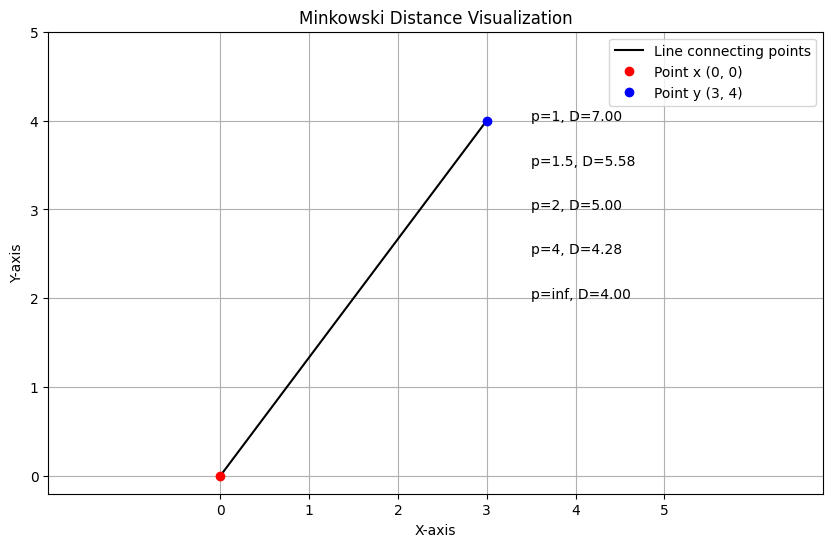

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

def minkowski_distance(x, y, p):
    """Calculates the Minkowski distance between two points."""
    if p == np.inf:
        return np.max(np.abs(np.array(x) - np.array(y)))
    else:
        return np.power(np.sum(np.power(np.abs(np.array(x) - np.array(y)), p)), 1/p)

def visualize_minkowski_distances(x, y, p_values):
    """Visualizes Minkowski distances for different p values."""

    plt.figure(figsize=(10, 6))

    plt.plot([x[0], y[0]], [x[1], y[1]], 'k-', label='Line connecting points')
    plt.plot(x[0], x[1], 'ro', label='Point x (0, 0)')
    plt.plot(y[0], y[1], 'bo', label='Point y (3, 4)')

    # Calculate max x and y to place text on the right
    max_x = max(x[0], y[0])
    max_y = max(x[1], y[1])

    for i, p in enumerate(p_values):
        distance = minkowski_distance(x, y, p)
        plt.text(max_x + 0.5, max_y - i * 0.5,  # Place text on the right
                 f'p={p}, D={distance:.2f}', fontsize=10)

    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.title('Minkowski Distance Visualization')
    plt.grid(True)
    plt.legend()
    plt.axis('equal')  # Equal scaling for x and y axes

    plt.xticks(np.arange(0, 6, 1))
    plt.yticks(np.arange(0, 6, 1))

    plt.show()

x = (0, 0)
y = (3, 4)
p_values = [1, 1.5, 2, 4, np.inf]  # Manhattan, p=1.5, Euclidean, p=4, Chebyshev

visualize_minkowski_distances(x, y, p_values)

## Superellipse to Illustrate Minkowski Distance

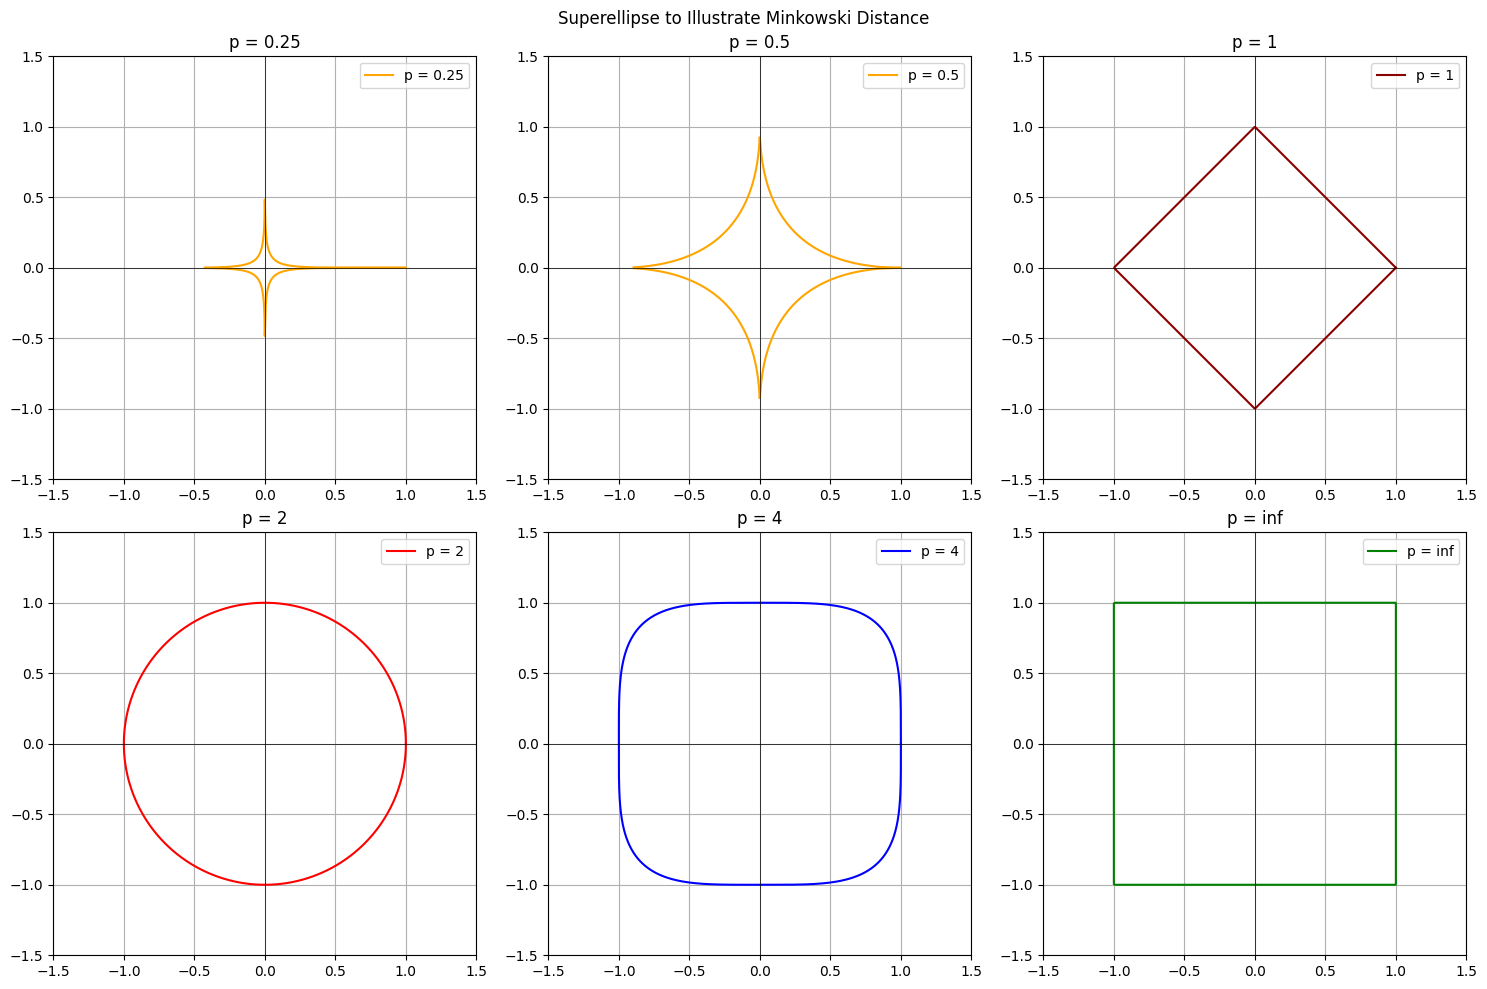

In [ ]:


import numpy as np
import matplotlib.pyplot as plt

def minkowski_unit_circle(p, resolution=1000):
    """
    Generates points for a Minkowski unit circle for a given p.

    Args:
        p: The order of the Minkowski distance.
        resolution: Number of points to generate.

    Returns:
        x, y: Arrays of x and y coordinates for the unit circle.
    """
    angles = np.linspace(0, 2 * np.pi, resolution)
    x = np.cos(angles)
    y = np.sin(angles)

    if p == np.inf:
        # Chebyshev distance (L-infinity)
        x_unit = np.sign(x)
        y_unit = np.sign(y)
        x_unit[x_unit == 0] = 1 # avoid division by zero
        y_unit[y_unit == 0] = 1
        return x / np.max(np.abs(np.array([x, y])), axis=0), y / np.max(np.abs(np.array([x, y])), axis=0)

    elif p == 0:
      return None, None #L0 norm results in a diamond, not a circle.

    else:
        # General Minkowski distance
        return x / (np.abs(x)**p + np.abs(y)**p)**(1/p), y / (np.abs(x)**p + np.abs(y)**p)**(1/p)


def plot_minkowski_circles(p_values):
    """
    Plots Minkowski unit circles for a list of p values.

    Args:
        p_values: List of p values to plot.
    """
    plt.figure(figsize=(15, 10)) # Adjust figure size for 2 rows and 3 columns
    colors = ['orange', 'orange', 'darkred', 'red', 'blue', 'green']  # Define colors

    for i, p in enumerate(p_values):
        x, y = minkowski_unit_circle(p)
        if x is not None and y is not None:
          plt.subplot(2, 3, i + 1) # 2 rows, 3 columns, plot i+1
          plt.plot(x, y, label=f'p = {p}', color=colors[i])  # Use defined color
          plt.xlim(-1.5, 1.5)
          plt.ylim(-1.5, 1.5)
          plt.axhline(0, color='black', linewidth=0.5)
          plt.axvline(0, color='black', linewidth=0.5)
          plt.title(f'p = {p}')
          plt.grid(True)
          plt.legend()
          plt.gca().set_aspect('equal', adjustable='box') # make x and y scales equal

        else:
          plt.subplot(2, 3, i + 1) # 2 rows, 3 columns, plot i+1
          plt.xlim(-1.5, 1.5)
          plt.ylim(-1.5, 1.5)
          plt.axhline(0, color='black', linewidth=0.5)
          plt.axvline(0, color='black', linewidth=0.5)
          plt.title(f'p = {p}')
          plt.text(0,0, "Not a circle", ha='center', va='center')
          plt.gca().set_aspect('equal', adjustable='box')


    plt.suptitle("Superellipse to Illustrate Minkowski Distance") # Set main title
    plt.tight_layout()
    plt.show()

p_values = [0.25, 0.5, 1, 2, 4, np.inf]
plot_minkowski_circles(p_values)

### Observations

- When $p = 1$ or greater, the shape is convex
- When $p = 2$, the shape is a circle
- As $p$ increase, the shapes more and more look like a square
- When $p$ is infinity, the shape is a square


## An Animation for Minkowski Distance as $p$ Varies

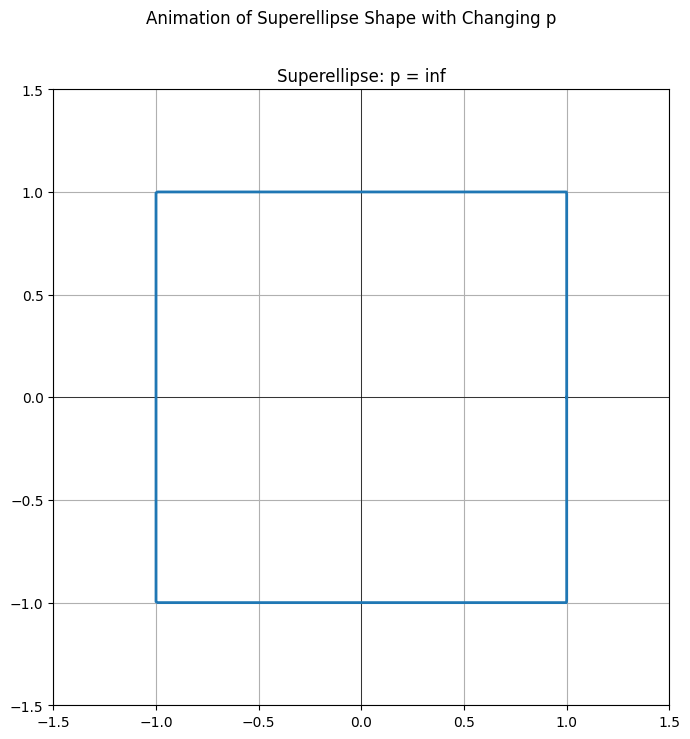

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def minkowski_unit_circle(p, resolution=1000):
    """
    Generates points for a Minkowski unit circle for a given p.

    Args:
        p: The order of the Minkowski distance.
        resolution: Number of points to generate.

    Returns:
        x, y: Arrays of x and y coordinates for the unit circle.
    """
    angles = np.linspace(0, 2 * np.pi, resolution)
    x = np.cos(angles)
    y = np.sin(angles)

    if p == np.inf:
        # Chebyshev distance (L-infinity)
        x_unit = np.sign(x)
        y_unit = np.sign(y)
        x_unit[x_unit == 0] = 1 # avoid division by zero
        y_unit[y_unit == 0] = 1
        return x / np.max(np.abs(np.array([x, y])), axis=0), y / np.max(np.abs(np.array([x, y])), axis=0)

    elif p == 0:
      return None, None #L0 norm results in a diamond, not a circle.

    else:
        # General Minkowski distance
        return x / (np.abs(x)**p + np.abs(y)**p)**(1/p), y / (np.abs(x)**p + np.abs(y)**p)**(1/p)

def animate_minkowski_circles(p_values, filename="minkowski_animation.gif", save=False):
    """
    Animates Minkowski unit circles for a list of p values.

    Args:
        p_values: List of p values to animate.
        filename: Name of the file to save the animation (if save=True).
        save: Whether to save the animation to a file.
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)
    line, = ax.plot([], [], lw=2)
    title = ax.set_title('')

    def init():
        line.set_data([], [])
        return line, title

    def animate(i):
        p = p_values[i]
        x, y = minkowski_unit_circle(p)
        if x is not None and y is not None:
            line.set_data(x, y)
            title.set_text(f'Superellipse: p = {p:.2f}')
        else:
            line.set_data([], [])
            title.set_text(f'Superellipse: p = {p:.2f} (Not a circle)')
        return line, title

    ani = animation.FuncAnimation(fig, animate, frames=len(p_values), init_func=init, blit=True, repeat=True)
    plt.suptitle("Animation of Superellipse Shape with Changing p")

    if save:
        ani.save(filename, writer='pillow')  # You can also try 'ffmpeg'
    else:
        plt.show()

# Define the p values for the animation
p_values = list(np.arange(0.01, 1.00, 0.05)) + [1, 1.5, 2, 3, 4, 8, 16, 32, 64, np.inf]

animate_minkowski_circles(p_values, "minkowski_animation.gif", save=True)

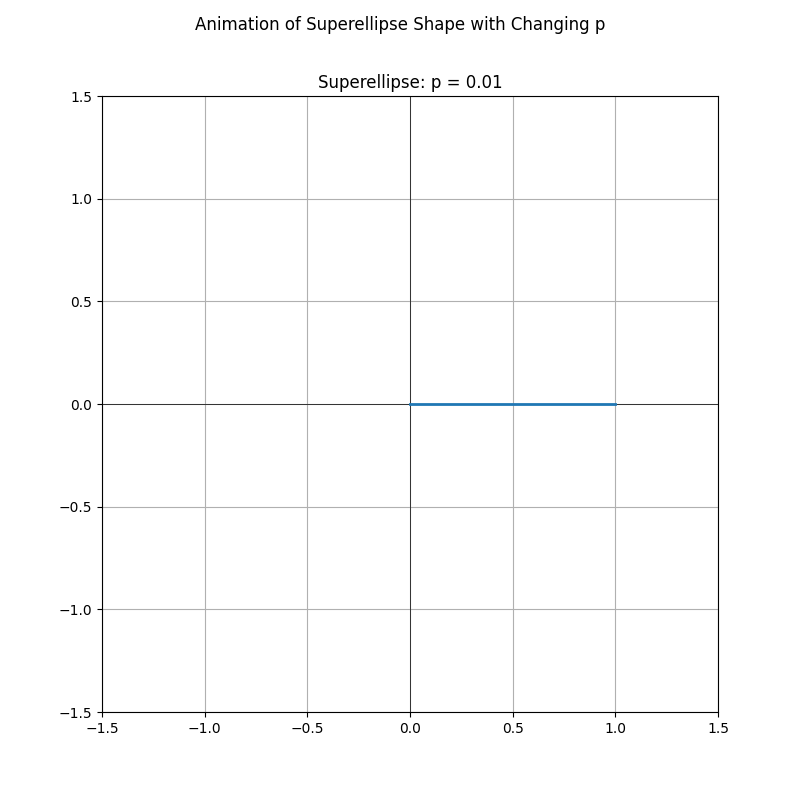

In [ ]:
from IPython.display import Image, display

def display_gif(filename):
    """Displays an animated GIF file in Google Colab."""
    try:
        with open(filename, 'rb') as f:
            display(Image(data=f.read(), format='png')) #colab requires format='png'
    except FileNotFoundError:
        print(f"File '{filename}' not found.")

display_gif('minkowski_animation.gif')

## Distance over $p$

The distance between (0,0) and (3,4) is $L_p$ is:

$$ d(p) = \left( 3^p + 4^p \right)^{1/p} $$

TODO:
- Draw the graph of $d(p)$ as $p$ varies.
- Try to calculate $d(p)$ when $p$ is close to 0 or large (will be overflowed)


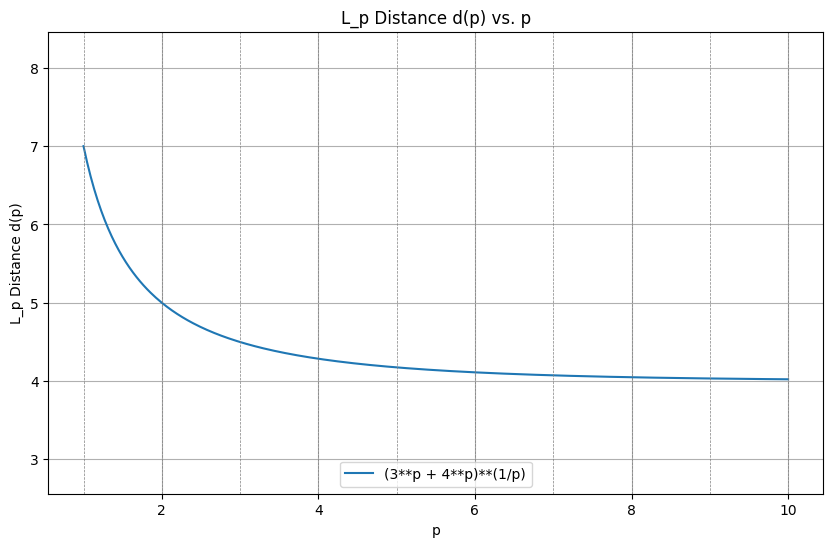

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_lp_distance(p):
    """Calculates L_p distance for given p, handling small and large p."""
    if p == 0:
        return np.exp((np.log(3) + np.log(4)) / 2)  # Limit as p -> 0
    elif abs(p) < 1e-8: # handle very small p values
        return np.exp((np.log(3) + np.log(4)) / 2) # use the limit
    elif p > 1e2: # handle very large p values
        return max(3, 4) # limit as p -> infinity
    else:
        try:
            return (3**p + 4**p)**(1/p)
        except OverflowError:
            if p > 0:
                return max(3,4) # handle if overflow happens for very large p
            else:
                return np.exp((np.log(3) + np.log(4)) / 2) # when p is negative and small, use the limit.

def plot_lp_distance():
    """Plots L_p distance for p in the range [1, 10]."""

    p_values = np.linspace(1, 10, 400)
    distances = [calculate_lp_distance(p) for p in p_values]

    plt.figure(figsize=(10, 6))

    plt.plot(p_values, distances, label='(3**p + 4**p)**(1/p)') # Add label for legend

    plt.xlabel('p')
    plt.ylabel('L_p Distance d(p)')
    plt.title('L_p Distance d(p) vs. p')
    plt.grid(True)
    plt.axis('equal') # make x y scale equally

    for i in range(1, 11): # Draw lines for x = 1, 2, ..., 10
        plt.axvline(x=i, color='gray', linestyle='--', linewidth=0.5)

    plt.legend()
    plt.show()

plot_lp_distance()

#### Observations

- When $p = 1$
- When $p$ becomes large

In [13]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.minkowski.html

import numpy as np
from scipy.spatial.distance import minkowski

a = (0, 0)
b = (3, 4)

p = 0.001
distance = minkowski(a, b, p)
print(f"The Minkowski distance between {a} and {b} with p={p} is: {distance}")

p = 100
distance = minkowski(a, b, p)
print(f"The Minkowski distance between {a} and {b} with p={p} is: {distance}")


The Minkowski distance between (0, 0) and (3, 4) with p=0.001 is: 3.7118530961622485e+301
The Minkowski distance between (0, 0) and (3, 4) with p=100 is: 4.000000000000013


In [12]:
import math

def stable_expr(p):
    a, b = 3.0, 4.0

    def compute(p_):
        log_a, log_b = math.log(a), math.log(b)
        pa, pb = p_ * log_a, p_ * log_b
        M = max(pa, pb)
        log_sum = math.log(math.exp(pa - M) + math.exp(pb - M)) + M
        return math.exp(log_sum / p_)

    try:
        return compute(p)
    except OverflowError:
        return compute(round(p, 4))


stable_expr(0.001)
# stable_expr(100)


3.711853096161915e+301

# Compare the Distances

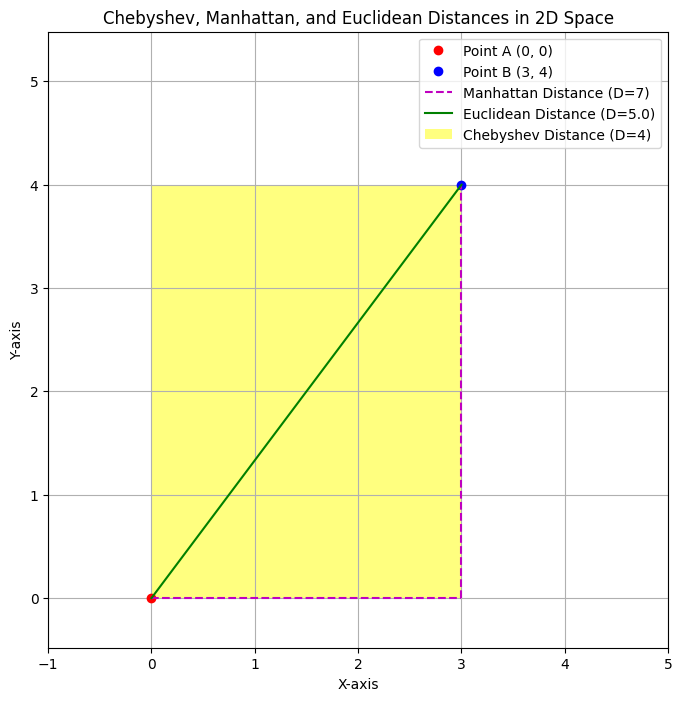

In [ ]:


import matplotlib.pyplot as plt
import numpy as np

def manhattan_distance(p1, p2):
    """Calculates Manhattan distance between two points."""
    return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])

def euclidean_distance(p1, p2):
    """Calculates Euclidean distance between two points."""
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

def chebyshev_distance(p1, p2):
    """Calculates Chebyshev distance between two points."""
    return max(abs(p1[0] - p2[0]), abs(p1[1] - p2[1]))

def plot_distances(p1, p2):
    """Plots the points and distances with equal x and y scales."""

    manhattan_d = manhattan_distance(p1, p2)
    euclidean_d = euclidean_distance(p1, p2)
    chebyshev_d = chebyshev_distance(p1, p2)

    plt.figure(figsize=(8, 8))  # Make figure square for equal scales

    # Plot points
    plt.plot(p1[0], p1[1], 'ro', label=f'Point A ({p1[0]}, {p1[1]})')
    plt.plot(p2[0], p2[1], 'bo', label=f'Point B ({p2[0]}, {p2[1]})')

    # Plot Manhattan distance
    plt.plot([p1[0], p2[0]], [p1[1], p1[1]], 'm--', label=f'Manhattan Distance (D={manhattan_d})')
    plt.plot([p2[0], p2[0]], [p1[1], p2[1]], 'm--')

    # Plot Euclidean distance
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'g-', label=f'Euclidean Distance (D={euclidean_d})')

    # Plot Chebyshev distance (shaded area)
    chebyshev_rect = plt.Rectangle((min(p1[0], p2[0]), min(p1[1], p2[1])),
                                    abs(p1[0] - p2[0]), abs(p1[1] - p2[1]),
                                    facecolor='yellow', alpha=0.5, label=f'Chebyshev Distance (D={chebyshev_d})')
    plt.gca().add_patch(chebyshev_rect)

    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.title("Chebyshev, Manhattan, and Euclidean Distances in 2D Space")
    plt.grid(True)
    plt.legend()
    plt.axis('equal')  # Set equal scaling for x and y axes

    # Customize y-axis ticks
    plt.xticks(np.arange(-1, 6, 1))
    plt.yticks(np.arange(-1, 7, 1)) # Only show ticks at 2, 3, 4, 5, 6

    plt.show()

point_a = (0, 0)
point_b = (3, 4)

plot_distances(point_a, point_b)

# Measure Space & Triangle Inequality



## Distance (Metric) in $L^p$ Space

In $L^p$ space, the distance between two functions is defined using the $L^p$ norm of their difference.

**Definition:**

Let $(S, \mu)$ be a measure space, and let $1 \leq p < \infty$. For functions $f$ and $g$ in $L^p(S, \mu)$, the distance between $f$ and $g$, denoted as $d_p(f, g)$, is defined as:

$$ d_p(f, g) = \|f - g\|_p = \left( \int_S |f(x) - g(x)|^p \, d\mu(x) \right)^{1/p} $$

**Explanation:**

* **$L^p$ Space:** $L^p(S, \mu)$ is the space of measurable functions $f$ on $S$ such that the integral of $|f(x)|^p$ with respect to the measure $\mu$ is finite.
* **$L^p$ Norm:** The $L^p$ norm of a function $h$ is defined as:

$$ \|h\|_p = \left( \int_S |h(x)|^p \, d\mu(x) \right)^{1/p} $$

* **Distance:** The distance $d_p(f, g)$ measures the "difference" between the functions $f$ and $g$ using the $L^p$ norm. It calculates the $L^p$ norm of the function $f - g$.

**Metric Properties:**

The distance $d_p(f, g)$ in $L^p$ space satisfies the properties of a metric:

1.  **Non-negativity:** $d_p(f, g) \geq 0$, and $d_p(f, g) = 0$ if and only if $f = g$ almost everywhere (i.e., they are equal except possibly on a set of measure zero).
2.  **Symmetry:** $d_p(f, g) = d_p(g, f)$.
3.  **Triangle inequality:** $d_p(f, h) \leq d_p(f, g) + d_p(g, h)$ for any function $f,g,h$ in $L^p(S, \mu)$.

## Applications

* Approximation theory
* Functional analysis
* Partial differential equations
* Numerical analysis


## Triangle Inequality in $L^p$ Space

The triangle inequality in $L^p$ space, derived from Minkowski's inequality, states that for functions $f$ and $g$ in $L^p(S, \mu)$, the $L^p$ norm of their sum is less than or equal to the sum of their individual $L^p$ norms.

**Formal Statement:**

Let $(S, \mu)$ be a measure space, and let $1 \leq p < \infty$. For functions $f$ and $g$ in $L^p(S, \mu)$, we have:

$$ \|f + g\|_p \leq \|f\|_p + \|g\|_p $$

where:

$$ \|f\|_p = \left( \int_S |f(x)|^p \, d\mu(x) \right)^{1/p} $$

is the $L^p$ norm of $f$.

**Explanation:**

* **L^p Space:** $L^p(S, \mu)$ is the space of measurable functions $f$ on $S$ such that the integral of $|f(x)|^p$ with respect to the measure $\mu$ is finite.
* **Norm:** The $L^p$ norm, denoted by $\|f\|_p$, measures the "size" or "length" of the function $f$ in the $L^p$ space.
* **Triangle Inequality:** This property of norms ensures that the "length" of the sum of two vectors (or functions) is less than or equal to the sum of their individual "lengths."

**Significance:**

The triangle inequality is fundamental because it guarantees that $L^p$ spaces are normed vector spaces and, importantly, complete metric spaces (Banach spaces). This completeness is crucial for various applications in analysis, including:

* Functional analysis
* Partial differential equations
* Probability theory
* Fourier analysis

## Notes on Measure Space & Generalized Minkowski's Inequality

- The distances mentioned in this Notebook can be derived from general measure spaces in this section
- The distances mentioned in this Notebook satisfy Minkowski's inequality as they are special cases.
- The (Generalized) Minkowski's inequality in this section is for functions. By choosing the right functions, we can get the Minkowski's inequality for numbers (see below) (by replacing the function $g$ with $-g$)

## Triangle Inequality (1D and 2D)

**1. Triangle Inequality on the x-axis (1D Space):**

For any points $a, b, c$ on x-axis:

$$ |a - c| \le |a - b| + |b - c| $$

**2. Triangle Inequality in the xy-plane (2D Space):**

For any points
$A = (x_1, y_1)$, $B = (x_2, y_2)$, and $C = (x_3, y_3)$ on xy-plane:

$$ \sqrt{(x_3 - x_1)^2 + (y_3 - y_1)^2} \le \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2} + \sqrt{(x_3 - x_2)^2 + (y_3 - y_2)^2} $$

i.e.

$$ \overline{CA} \le \overline{AB} + \overline{CB} $$

where $\overline{CA}$, $\overline{AB}$, $\overline{CB}$ represent the lengths of the sides.


CA: 2.23606797749979
AB + BC: 6.478708664619075
Is CA < AB + BC? True


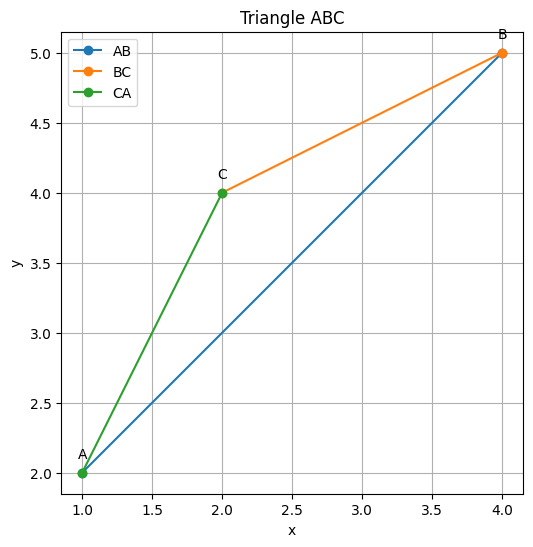

In [ ]:
import matplotlib.pyplot as plt

# Define coordinates for vertices A, B, and C
A = (1, 2)
B = (4, 5)
C = (2, 4)

# Calculate distances
AB = euclidean_distance(A, B)
BC = euclidean_distance(B, C)
CA = euclidean_distance(C, A)

# Check triangle inequality
print(f"CA: {CA}")
print(f"AB + BC: {AB + BC}")
print(f"Is CA < AB + BC? {CA < AB + BC}")

# Plot the triangle
plt.figure(figsize=(6, 6))
plt.plot([A[0], B[0]], [A[1], B[1]], marker='o', label='AB')
plt.plot([B[0], C[0]], [B[1], C[1]], marker='o', label='BC')
plt.plot([C[0], A[0]], [C[1], A[1]], marker='o', label='CA')

# Add labels for vertices
plt.annotate('A', A, textcoords="offset points", xytext=(0,10), ha='center')
plt.annotate('B', B, textcoords="offset points", xytext=(0,10), ha='center')
plt.annotate('C', C, textcoords="offset points", xytext=(0,10), ha='center')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Triangle ABC')
plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')  # Equal aspect ratio
plt.show()


# Generalized Mean

## Definition of Generalized Mean (Power Mean)

If $p$ is a non-zero real number, and $x_1, \dots, x_n$ are positive real numbers, then the **generalized mean** or **power mean** with exponent $p$ of these positive real numbers is:

$$ M_p(x_1,\dots,x_n) = \left( \frac{1}{n} \sum_{i=1}^n x_i^p \right)^{{1}/{p}} . $$

For $p = 0$ we set it equal to the geometric mean (which is the limit of means with exponents approaching zero, as proved below):

$$ M_0(x_1, \dots, x_n) = \left(\prod_{i=1}^n x_i\right)^{1/n} . $$

Furthermore, for a sequence of positive weights $w_i$ we define the **weighted power mean** as:

$$ M_p(x_1,\dots,x_n) = \left(\frac{\sum_{i=1}^n w_i x_i^p}{\sum_{i=1}^n w_i} \right)^{{1}/{p}} $$

and when $p = 0$, it is equal to the weighted geometric mean:

$$ M_0(x_1,\dots,x_n) = \left(\prod_{i=1}^n x_i^{w_i}\right)^{1 / \sum_{i=1}^n w_i} . $$

The unweighted means correspond to setting all $w_i = 1$.

## Special Cases of Generalized Mean

A few particular values of $p$ yield special cases with their own names:

* **Minimum:**
    $$ M_{-\infty}(x_1,\dots,x_n) = \lim_{p\to-\infty} M_p(x_1,\dots,x_n) = \min \{x_1,\dots,x_n\} $$

* **Harmonic Mean:**
    $$ M_{-1}(x_1,\dots,x_n) = \frac{n}{\frac{1}{x_1}+\dots+\frac{1}{x_n}} $$

* **Geometric Mean:**
    $$ M_0(x_1,\dots,x_n) = \lim_{p\to0} M_p(x_1,\dots,x_n) = \sqrt[n]{x_1\cdot\dots\cdot x_n} $$

* **Arithmetic Mean:**
    $$ M_1(x_1,\dots,x_n) = \frac{x_1 + \dots + x_n}{n} $$

* **Root Mean Square (Quadratic Mean):**
    $$ M_2(x_1,\dots,x_n) = \sqrt{\frac{x_1^2 + \dots + x_n^2}{n}} $$

* **Cubic Mean:**
    $$ M_3(x_1,\dots,x_n) = \sqrt[3]{\frac{x_1^3 + \dots + x_n^3}{n}} $$

* **Maximum:**
    $$ M_{+\infty}(x_1,\dots,x_n) = \lim_{p\to\infty} M_p(x_1,\dots,x_n) = \max \{x_1,\dots,x_n\} $$




## Inequality of Power Means

In general, if $p < q$, then

$$ M_p(x_1, \dots, x_n) \le M_q(x_1, \dots, x_n) $$

and the two means are equal if and only if $x_1 = x_2 = ... = x_n$.

The inequality is true for real values of $p$ and $q$, as well as positive and negative infinity values.

## Arithmetic Mean - Geometric Mean Inequality (AM-GM)

For any list of $n$ nonnegative real numbers $x_1, x_2, . . . , x_n$,

$$ \frac{x_1 + x_2 + \cdots + x_n}{n} \ge \sqrt[n]{x_1 \cdot x_2 \cdots x_n} \,, $$

and that equality holds if and only if $x_1 = x_2 = \cdots = x_n$.

# References

- https://www.math.uh.edu/~dlabate/PagesfromAnalysis.pdf
- Wikipedia
- https://docs.scipy.org/doc/scipy/reference/spatial.distance.html


# Distances in Probability Distributions

- Distance between a point $P$ and a distribution $D$
- Distance between two distributions

## Mahalanobis Distance

A probability distribution $Q$ on $\mathbb{R}^N$, with mean $\vec{\mu} = (\mu_1, \mu_2, \mu_3, \dots, \mu_N)^T$ and positive semi-definite covariance matrix $\Sigma$.

The Mahalanobis distance of a point $\vec{x} = (x_1, x_2, x_3, \dots, x_N)^T$ from $Q$ is:

$$ d_M(\vec{x}, Q) = \sqrt{(\vec{x} - \vec{\mu})^T \Sigma^{-1} (\vec{x} - \vec{\mu})} $$

**Mahalanobis Distance Between Two Points:**

Given two points $\vec{x}$ and $\vec{y}$ in $\mathbb{R}^N$, the Mahalanobis distance between them with respect to $Q$ is:

$$ d_M(\vec{x}, \vec{y}; Q) = \sqrt{(\vec{x} - \vec{y})^T \Sigma^{-1} (\vec{x} - \vec{y})} $$

Note: $d_M(\vec{x}, Q) = d_M(\vec{x}, \vec{\mu}; Q)$.

## Visualisation of Mahalanobis Distance

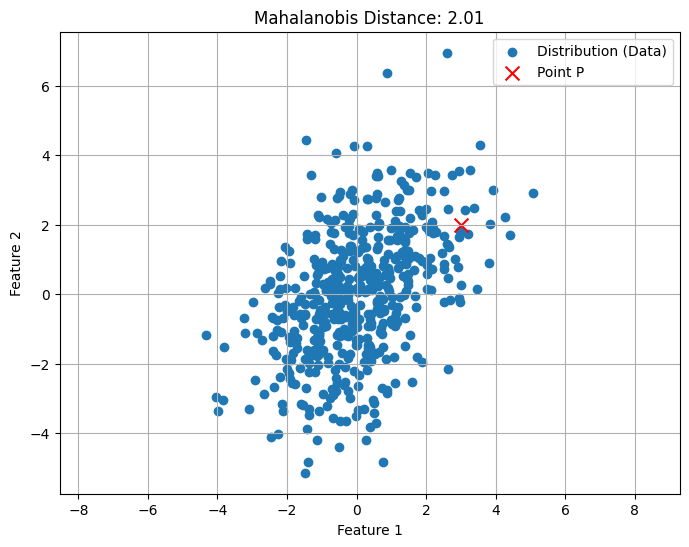

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance

def visualize_mahalanobis(data, point):
    """Visualizes Mahalanobis distance between a point and a distribution.

    Args:
        data: A numpy array representing the distribution (e.g., sample points).
        point: A numpy array representing the point to calculate the distance from.
    """

    # Calculate the covariance matrix of the data
    cov_matrix = np.cov(data.T)

    # Calculate the inverse covariance matrix
    inv_cov_matrix = np.linalg.inv(cov_matrix)

    # Calculate Mahalanobis distance
    mahalanobis_dist = distance.mahalanobis(point, np.mean(data, axis=0), inv_cov_matrix)

    # Plot the data and the point
    plt.figure(figsize=(8, 6))
    plt.scatter(data[:, 0], data[:, 1], label='Distribution (Data)')
    plt.scatter(point[0], point[1], c='red', marker='x', s=100, label='Point P')

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(f'Mahalanobis Distance: {mahalanobis_dist:.2f}')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')  # Ensure equal scaling for x and y axes
    plt.show()

# Example usage:
# Generate sample data (a 2D Gaussian distribution)
mean = [0, 0]
covariance = [[2, 1], [1, 3]]
data = np.random.multivariate_normal(mean, covariance, 500)

# Define a point to calculate the Mahalanobis distance from
point = np.array([3, 2])

# Visualize the Mahalanobis distance
visualize_mahalanobis(data, point)

### Applications of Mahalanobis Distance

- cluster analysis
- classification techniques

In [ ]:

import numpy as np
from scipy.spatial.distance import mahalanobis

# Example data
X = np.array([[1, 2], [1.5, 1.8], [5, 8], [8, 8], [1, 0.6], [9, 11]])

# Calculate the mean and covariance matrix
mu = np.mean(X, axis=0)
cov = np.cov(X, rowvar=False)

# Calculate the inverse of the covariance matrix
inv_cov = np.linalg.inv(cov)

# New data point
new_point = np.array([2, 3])

# Calculate Mahalanobis distance
mahalanobis_dist = mahalanobis(new_point, mu, inv_cov)
print(f"Mahalanobis Distance: {mahalanobis_dist}")

# Example usage for two points
point1 = np.array([1,2])
point2 = np.array([3,4])
mahalanobis_dist_points = mahalanobis(point1, point2, inv_cov)
print(f"Mahalanobis distance between point1 and point2: {mahalanobis_dist_points}")


Mahalanobis Distance: 0.6756776314785753
Mahalanobis distance between point1 and point2: 0.5958056883094742


In [ ]:
import numpy as np
from sklearn.covariance import EmpiricalCovariance
from scipy.spatial import distance

# Sample data (replace with your data)
data = np.array([[1, 2], [2, 3], [3, 4], [10, 1]])

# Calculate covariance matrix
cov = EmpiricalCovariance().fit(data).covariance_

# Calculate mean
mean = np.mean(data, axis=0)

# Calculate Mahalanobis distance for each point
mahalanobis_distances = [distance.mahalanobis(x, mean, np.linalg.inv(cov)) for x in data]

print("Mahalanobis Distances:", mahalanobis_distances)

Mahalanobis Distances: [np.float64(1.5275252316519468), np.float64(0.5773502691896257), np.float64(1.5275252316519468), np.float64(1.7320508075688772)]


In [14]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.mahalanobis.html

import numpy as np
from scipy.spatial.distance import mahalanobis
from sklearn.covariance import EmpiricalCovariance

# Sample data (replace with your data)
data = np.array([[1, 2], [2, 3], [3, 4], [10, 1]])

# Calculate covariance matrix
cov = EmpiricalCovariance().fit(data).covariance_

# Calculate mean
mean = np.mean(data, axis=0)

# Calculate Mahalanobis distance for each point
mahalanobis_distances = [mahalanobis(x, mean, np.linalg.inv(cov)) for x in data]

print("Mahalanobis Distances:", mahalanobis_distances)


Mahalanobis Distances: [np.float64(1.5275252316519468), np.float64(0.5773502691896257), np.float64(1.5275252316519468), np.float64(1.7320508075688772)]


## Kullback-Leibler (KL) Divergence

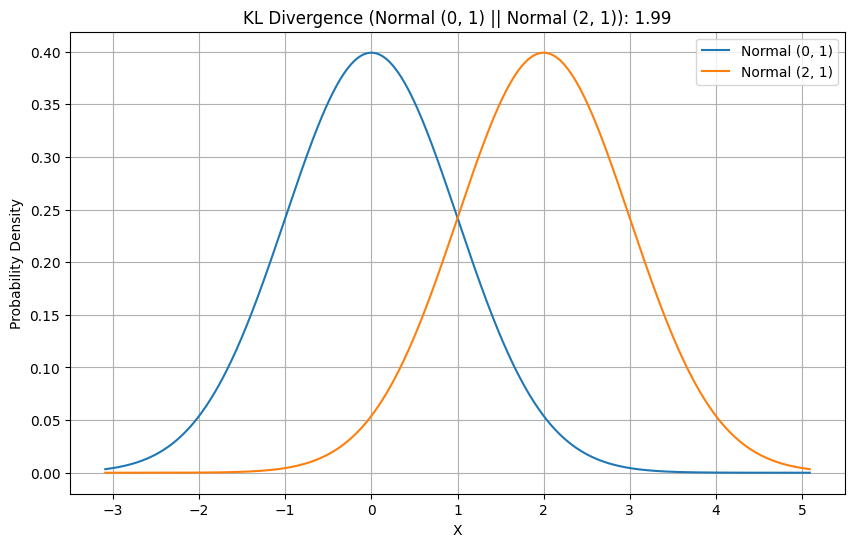

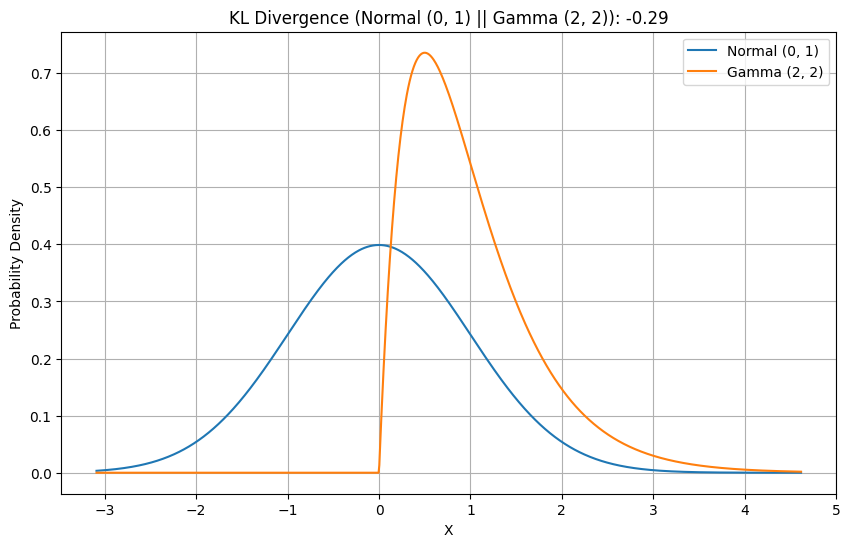

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gamma

def kl_divergence(p, q):
    """Calculates the Kullback-Leibler divergence between two distributions."""
    # Ensure distributions are discrete or continuous with proper PDF/PMF
    # This example assumes continuous distributions and uses numerical approximation

    # Generate x values for numerical integration
    x = np.linspace(min(p.ppf(0.001), q.ppf(0.001)), max(p.ppf(0.999), q.ppf(0.999)), 1000)

    # Calculate PDFs
    pdf_p = p.pdf(x)
    pdf_q = q.pdf(x)

    # Handle cases where q(x) is zero to prevent division by zero
    valid_indices = pdf_q > 0
    pdf_p = pdf_p[valid_indices]
    pdf_q = pdf_q[valid_indices]

    # Calculate KL divergence using numerical integration (approximation)
    kl = np.sum(pdf_p * np.log(pdf_p / pdf_q)) * (x[1]-x[0])

    return kl

def visualize_kl_divergence(p, q, p_label="Distribution P", q_label="Distribution Q"):
    """Visualizes two distributions and their KL divergence."""

    x = np.linspace(min(p.ppf(0.001), q.ppf(0.001)), max(p.ppf(0.999), q.ppf(0.999)), 1000)
    pdf_p = p.pdf(x)
    pdf_q = q.pdf(x)

    kl = kl_divergence(p, q)

    plt.figure(figsize=(10, 6))
    plt.plot(x, pdf_p, label=f'{p_label}')
    plt.plot(x, pdf_q, label=f'{q_label}')
    plt.xlabel('X')
    plt.ylabel('Probability Density')
    plt.title(f'KL Divergence ({p_label} || {q_label}): {kl:.2f}')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage:
# Example 1: Comparing two normal distributions
mean1, std1 = 0, 1
mean2, std2 = 2, 1
p1 = norm(mean1, std1)
q1 = norm(mean2, std2)

visualize_kl_divergence(p1, q1, "Normal (0, 1)", "Normal (2, 1)")

# Example 2: Comparing normal and gamma distributions
alpha, beta = 2, 2
p2 = norm(mean1, std1)
q2 = gamma(alpha, scale=1/beta)

visualize_kl_divergence(p2, q2, "Normal (0, 1)", "Gamma (2, 2)")

## Jensen-Shannon (JS) Divergence

# Famous Inequalities

## Cauchy–Schwarz inequality

### Cauchy–Schwarz Inequality in ($\mathbb{R}^n$)

For real number $u_i$, $v_i$:

$$ \biggl(\sum_{i=1}^n u_i v_i\biggr)^2 \leq \biggl(\sum_{i=1}^n u_i^2\biggr) \biggl(\sum_{i=1}^n v_i^2\biggr). $$

The Cauchy-Schwarz inequality can be proved using only elementary algebra.

### Cauchy-Schwarz Inequality in $\mathbb{C}^n$ (Complex Space)

$$ \left| \sum_{i=1}^n u_i \overline{v_i} \right|^2 \leq \left( \sum_{i=1}^n |u_i|^2 \right) \left( \sum_{i=1}^n |v_i|^2 \right) $$

where:

* $u_i$ and $v_i$ are complex numbers.
* $\overline{v_i}$ denotes the complex conjugate of $v_i$.
* $|u_i|$ and $|v_i|$ denote the magnitudes (absolute values) of $u_i$ and $v_i$, respectively.

### Cauchy-Schwarz Inequality for Functions

For real-valued functions $f$, $g$:


$$ \left(\int_{\mathbb{R}^n} f(x) g(x) \, dx\right)^2 \leq \left(\int_{\mathbb{R}^n} f(x)^2 \, dx\right) \left(\int_{\mathbb{R}^n} g(x)^2 \, dx\right). $$


### Cauchy-Schwarz Inequality for Random Variables

Given two random variables $X$ and $Y$, the Cauchy-Schwarz inequality states:

$$ |E(XY)|^2 \le E(X^2) E(Y^2) $$

where:

* $E(XY)$ denotes the expected value (mean) of the product of $X$ and $Y$.
* $E(X^2)$ denotes the expected value of $X$ squared.
* $E(Y^2)$ denotes the expected value of $Y$ squared.

##  Hölder's Inequality

Hölder's inequality is a generalized form for Cauchy-Schwarz Inequality

### Hölder's Inequality on $R^n$ or $C^n$

$$ \sum_{k=1}^n |x_k y_k| \le \biggl( \sum_{k=1}^n |x_k|^p \biggr)^{\frac{1}{p}} \biggl( \sum_{k=1}^n |y_k|^q \biggr)^{\frac{1}{q}} \text{ for all } (x_1, \dots, x_n), (y_1, \dots, y_n) \in \mathbb{R}^n \text{ or } \mathbb{C}^n. $$

For any $(r, s) \in \mathbb{R}_+$:

$$ \biggl( \sum_{k=1}^n |x_k|^r |y_k|^s \biggr)^{r+s} \le \biggl( \sum_{k=1}^n |x_k|^{r+s} \biggr)^{r} \biggl( \sum_{k=1}^n |y_k|^{r+s} \biggr)^{s}. $$

With real positive numbers $\lambda_i$ and $\lambda_a + \lambda_b + \cdots + \lambda_z = 1$:

$$ \sum_{k=1}^n |a_k|^{\lambda_a} |b_k|^{\lambda_b} \cdots |z_k|^{\lambda_z} \le \biggl( \sum_{k=1}^n |a_k| \biggr)^{\lambda_a} \biggl( \sum_{k=1}^n |b_k| \biggr)^{\lambda_b} \cdots \biggl( \sum_{k=1}^n |z_k| \biggr)^{\lambda_z}. $$

Equality holds if and only if $|a_1| : |a_2| : \cdots : |a_n| = |b_1| : |b_2| : \cdots : |b_n| = \cdots = |z_1| : |z_2| : \cdots : |z_n|$.


### Hölder's Inequality with Lebesgue Measure

If $S$ is a measurable subset of $\mathbb{R}^n$ with the Lebesgue measure, and $f$ and $g$ are measurable real- or complex-valued functions on $S$, then Hölder's inequality is:

$$ \int_S |f(x) g(x)| \, \mathrm{d}x \le \biggl( \int_S |f(x)|^p \, \mathrm{d}x \biggr)^{\frac{1}{p}} \biggl( \int_S |g(x)|^q \, \mathrm{d}x \biggr)^{\frac{1}{q}}. $$

### Hölder's Inequality with Probability Measure

For the probability space $(\Omega, \mathcal{F}, \mathbb{P})$, let $\mathbb{E}$ denote the expectation operator. For real- or complex-valued random variables $X$ and $Y$ on $\Omega$, Hölder's inequality reads:

$$ \mathbb{E}[|XY|] \leqslant \left( \mathbb{E}[|X|^p] \right)^{\frac{1}{p}} \left( \mathbb{E}[|Y|^q] \right)^{\frac{1}{q}}. $$



## Jensen's Inequality

### Jensen's Inequality for Real-Valued Numbers

Let $\phi$ be a convex function on an interval $I$ of the real line. Let $x_1, x_2, \dots, x_n$ be numbers in $I$, and let $w_1, w_2, \dots, w_n$ be non-negative weights such that $\sum_{i=1}^n w_i = 1$. Then:

$$ \phi\left( \sum_{i=1}^n w_i x_i \right) \le \sum_{i=1}^n w_i \phi(x_i) $$

The convex function of the weighted average of a set of numbers is less than or equal to the weighted average of the convex function evaluated at each number.

A function $\phi$ is convex if for any $x, y$ in its domain and $t \in [0, 1]$, $\phi(tx + (1-t)y) \le t\phi(x) + (1-t)\phi(y)$.



### Jensen's Inequality for Real-Valued Functions

Let $(\Omega, \Sigma, \mu)$ be a measure space with $\mu(\Omega) = 1$ (i.e., \mu is a probability measure). Let g be a real-valued integrable function on \Omega, and let \phi be a convex function on the real line. Then:

$$ \phi\left( \int_\Omega g \, d\mu \right) \le \int_\Omega \phi(g) \, d\mu $$


In other word, the convex function of the expected value of a random variable is less than or equal to the expected value of the convex function of that random variable.

### For Discrete Probability Distributions

If $X$ is a random variable with values $x_i$ and probabilities $p_i$, and $\phi$ is a convex function, then:

$$ \phi\left( \sum_i p_i x_i \right) \le \sum_i p_i \phi(x_i) $$

### For Continuous Probability Distribution

If $X$ is a random variable with probability density function $f(x)$, and $\phi$ is a convex function, then:

$$ \phi\left( \int x f(x) \, dx \right) \le \int \phi(x) f(x) \, dx $$


### Jensen's Inequality Turns into AM–GM Inequality

The function $\log(x)$ is concave, so substituting $\varphi(x) = \log(x)$ in the Jensen's inequality above establishes the (logarithm of the) familiar arithmetic-mean/geometric-mean inequality:

$$ \log\left( \frac{\sum_{i=1}^n x_i}{n} \right) \geq \frac{\sum_{i=1}^n \log(x_i)}{n} $$
$$ \exp\left( \log\left( \frac{\sum_{i=1}^n x_i}{n} \right) \right) \geq \exp\left( \frac{\sum_{i=1}^n \log(x_i)}{n} \right) $$
$$ \frac{x_1 + x_2 + \cdots + x_n}{n} \geq \sqrt[n]{x_1 \cdot x_2 \cdots x_n} $$


### Jensen's Inequality: Probabilistic Form

Let $(\Omega, \mathfrak{F}, \operatorname{P})$ be a probability space, $X$ an integrable real-valued random variable and $\varphi$ a convex function. Then:

$$ \varphi\left( \operatorname{E}[X] \right) \leq \operatorname{E} \left[ \varphi(X) \right]. $$

Jensen's inequality states that for a convex function $\varphi$ and a random variable $X$, the convex function of the expected value of $X$ is less than or equal to the expected value of the convex function of $X$.

The equality holds if and only if $\varphi$ is a linear function on some convex set $A$ such that $\mathrm{P}(X \in A) = 1$.

https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.jensenshannon.html